<a href="https://colab.research.google.com/github/vardhan999505/AIDriven-Archaeological-Site-Mapping/blob/main/Milestone4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏛️ AI-Driven Archaeological Site Mapping
## Milestone 4 — Dashboard & Final Reporting
**Weeks 7–8** | Streamlit Dashboard → Model Report → Demo Presentation




---
## 📦 Step 1 — Install Libraries

In [1]:
!pip install -q streamlit streamlit-folium pyngrok
!pip install -q torch torchvision segmentation-models-pytorch
!pip install -q xgboost scikit-learn shap folium branca
!pip install -q opencv-python-headless matplotlib seaborn Pillow
!pip install -q ultralytics

import os, json, glob, shutil, pickle, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from pathlib import Path
import torch
import segmentation_models_pytorch as smp
warnings.filterwarnings('ignore')

SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Libraries loaded!  Device: {DEVICE}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.2/529.2 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.8 MB/s eta 0:00:00
✅ Libraries loaded!  Device: cuda


---
## ☁️ Step 2 — Mount Drive & Restore All Milestone Outputs

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, json, glob, shutil
from pathlib import Path

# ── Drive folder paths — must match where M2 and M3 saved ─
DRIVE_BASE    = '/content/drive/MyDrive/Archaeological_AI'
DRIVE_PROJECT = f'{DRIVE_BASE}/project'
DRIVE_M2_OUT  = f'{DRIVE_BASE}/Milestone2_Output'
DRIVE_M3_OUT  = f'{DRIVE_BASE}/Milestone3_Output'

# Local Colab working directory
BASE_DIR      = '/content/archaeological_project'

def restore_from_drive(drive_src, local_dst):
    """Copy files from Google Drive to local Colab runtime."""
    if not os.path.exists(drive_src):
        print(f'     ⚠️  Not found on Drive: {drive_src}')
        return 0
    os.makedirs(local_dst, exist_ok=True)
    count = 0
    for item in Path(drive_src).rglob('*'):
        if item.is_file():
            rel  = item.relative_to(drive_src)
            dest = Path(local_dst) / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(item, dest)
            count += 1
    return count

print('Restoring all milestone outputs from Google Drive...')
print()

# ── Restore M1 outputs (split folders + metadata) ─────────
r1 = restore_from_drive(
    f'{DRIVE_PROJECT}/split/segmentation',
    f'{BASE_DIR}/split/segmentation'
)
r2 = restore_from_drive(
    f'{DRIVE_PROJECT}/processed',
    f'{BASE_DIR}/processed'
)
print(f'  M1 split/segmentation : {r1} files')
print(f'  M1 processed/         : {r2} files')

# ── Restore M2 outputs ────────────────────────────────────
# M2 saves: best_seg_model.pth, yolo_artifacts/weights/best.pt,
#           milestone2_metrics.json, result images
# All in: MyDrive/Archaeological_AI/Milestone2_Output/
r3 = restore_from_drive(
    DRIVE_M2_OUT,
    f'{BASE_DIR}/milestone2_output'
)
print(f'  M2 outputs            : {r3} files')

# ── Restore M3 outputs ────────────────────────────────────
# M3 saves: random_forest.pkl, xgboost.pkl, scaler.pkl, imputer.pkl,
#           milestone3_metrics.json, maps, results
# All in: MyDrive/Archaeological_AI/Milestone3_Output/
r4 = restore_from_drive(
    DRIVE_M3_OUT,
    f'{BASE_DIR}/milestone3_output'
)
print(f'  M3 outputs            : {r4} files')

# ── Define exact model file paths ─────────────────────────
META_PATH   = f'{BASE_DIR}/processed/milestone1_metadata.json'

# M2 model files — copied from Milestone2_Output
SEG_CKPT    = f'{BASE_DIR}/milestone2_output/best_seg_model.pth'
YOLO_CKPT   = f'{BASE_DIR}/milestone2_output/yolo_artifacts/weights/best.pt'
M2_METRICS  = f'{BASE_DIR}/milestone2_output/milestone2_metrics.json'

# M3 model files — copied from Milestone3_Output
RF_PKL      = f'{BASE_DIR}/milestone3_output/random_forest.pkl'
XGB_PKL     = f'{BASE_DIR}/milestone3_output/xgboost.pkl'
SCALER_PKL  = f'{BASE_DIR}/milestone3_output/scaler.pkl'
IMPUTER_PKL = f'{BASE_DIR}/milestone3_output/imputer.pkl'
M3_METRICS  = f'{BASE_DIR}/milestone3_output/milestone3_metrics.json'

# ── Verify all critical files ─────────────────────────────
print('\nVerifying all model files...')
all_ok = True
checks = [
    ('Metadata (M1)',     META_PATH),
    ('Seg model (M2)',    SEG_CKPT),
    ('YOLO weights (M2)', YOLO_CKPT),
    ('Random Forest (M3)',RF_PKL),
    ('XGBoost (M3)',      XGB_PKL),
    ('Scaler (M3)',       SCALER_PKL),
    ('Imputer (M3)',      IMPUTER_PKL),
    ('M2 metrics',        M2_METRICS),
    ('M3 metrics',        M3_METRICS),
]
for name, path in checks:
    ex = os.path.exists(path)
    print(f'  {"✅" if ex else "❌"} {name}')
    if not ex: all_ok = False

# ── Load metadata ──────────────────────────────────────────
if os.path.exists(META_PATH):
    with open(META_PATH) as f: meta = json.load(f)
    SEG_CLASSES     = meta['segmentation']['categories']
    DET_CLASSES     = meta['detection']['classes']
    IMG_SIZE        = tuple(meta['target_img_size'])
    NUM_SEG_CLASSES = len(SEG_CLASSES) + 1
    print(f'\n✅ Metadata loaded!')
    print(f'   Seg classes ({len(SEG_CLASSES)}): {SEG_CLASSES}')
    print(f'   Det classes ({len(DET_CLASSES)}): {DET_CLASSES}')
    print(f'   Image size: {IMG_SIZE}')
else:
    SEG_CLASSES=['vegetation','ruins','erosion']; DET_CLASSES=['artifact']
    IMG_SIZE=(640,640); NUM_SEG_CLASSES=4
    print('\n⚠️  Metadata not found — using defaults')

print()
if all_ok:
    print('🎉 All model files restored! Ready to load models.')
else:
    print('❌ Some files missing. Checklist:')
    print('   1. Did Milestone 2 last cell complete? (SEG + YOLO backup)')
    print('   2. Did Milestone 3 last cell complete? (pkl backup)')
    print('   3. Check Drive folders exist:')
    print(f'      {DRIVE_M2_OUT}')
    print(f'      {DRIVE_M3_OUT}')
    print('   4. List what IS in Drive M2 folder:')
    for fn in glob.glob(f'{DRIVE_M2_OUT}/**/*', recursive=True):
        if os.path.isfile(fn): print(f'      • {fn}')
    print('   5. List what IS in Drive M3 folder:')
    for fn in glob.glob(f'{DRIVE_M3_OUT}/**/*', recursive=True):
        if os.path.isfile(fn): print(f'      • {fn}')


Mounted at /content/drive
Restoring all milestone outputs from Google Drive...

  M1 split/segmentation : 440 files
  M1 processed/         : 7 files
  M2 outputs            : 8 files
  M3 outputs            : 11 files

Verifying all model files...
  ✅ Metadata (M1)
  ✅ Seg model (M2)
  ✅ YOLO weights (M2)
  ✅ Random Forest (M3)
  ✅ XGBoost (M3)
  ✅ Scaler (M3)
  ✅ Imputer (M3)
  ✅ M2 metrics
  ✅ M3 metrics

✅ Metadata loaded!
   Seg classes (2): ['ruins-vegetation', 'vegetation']
   Det classes (1): ['artifacts']
   Image size: (640, 640)

🎉 All model files restored! Ready to load models.


---
## 🔮 Step 3 — Load All Models

In [3]:
import torch.serialization
try:
    import numpy._core.multiarray
    torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])
except: pass

def load_ckpt(path, device):
    """Load PyTorch checkpoint safely across versions."""
    try: return torch.load(path, map_location=device, weights_only=False)
    except:
        try: return torch.load(path, map_location=device, weights_only=True)
        except:
            import numpy._core.multiarray as npcma
            with torch.serialization.safe_globals([npcma.scalar]):
                return torch.load(path, map_location=device, weights_only=True)

# ── Segmentation model ─────────────────────────────────────
MODEL_TYPE = 'unet'; ENCODER = 'resnet34'
seg_model = smp.Unet(encoder_name=ENCODER, encoder_weights=None,
                     in_channels=3, classes=NUM_SEG_CLASSES, activation=None)
if os.path.exists(SEG_CKPT):
    ckpt = load_ckpt(SEG_CKPT, DEVICE)
    state = ckpt['model_state'] if isinstance(ckpt,dict) and 'model_state' in ckpt else ckpt
    seg_model.load_state_dict(state)
    seg_model.to(DEVICE).eval()
    print('✅ Segmentation model (U-Net) loaded')
else:
    print(f'❌ Seg model not found at: {SEG_CKPT}')
    seg_model = None

# ── YOLO detection model ────────────────────────────────────
from ultralytics import YOLO
if os.path.exists(YOLO_CKPT):
    yolo_model = YOLO(YOLO_CKPT)
    print('✅ YOLO detection model loaded')
else:
    yolo_model = None
    print(f'❌ YOLO weights not found at: {YOLO_CKPT}')

# ── Erosion ML models ──────────────────────────────────────
rf_model = xgb_model = scaler = imputer = None
for attr, path, label in [
    ('rf_model',  RF_PKL,      'Random Forest'),
    ('xgb_model', XGB_PKL,     'XGBoost'),
    ('scaler',    SCALER_PKL,  'Scaler'),
    ('imputer',   IMPUTER_PKL, 'Imputer'),
]:
    if os.path.exists(path):
        with open(path,'rb') as f: globals()[attr] = pickle.load(f)
        print(f'✅ {label} loaded')
    else:
        print(f'❌ {label} not found at: {path}')

print('\n✅ All available models loaded!')


✅ Segmentation model (U-Net) loaded
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLO detection model loaded
✅ Random Forest loaded
✅ XGBoost loaded
✅ Scaler loaded
✅ Imputer loaded

✅ All available models loaded!


In [4]:
# ── DIAGNOSTIC: Run this BEFORE launching the dashboard ───
import os, glob, pickle, torch

BASE_DIR    = '/content/archaeological_project'
SEG_CKPT    = f'{BASE_DIR}/milestone2_output/best_seg_model.pth'
YOLO_CKPT   = f'{BASE_DIR}/milestone2_output/yolo_artifacts/weights/best.pt'
XGB_PKL     = f'{BASE_DIR}/milestone3_output/xgboost.pkl'
SCALER_PKL  = f'{BASE_DIR}/milestone3_output/scaler.pkl'
IMPUTER_PKL = f'{BASE_DIR}/milestone3_output/imputer.pkl'

print('='*55)
print('DIAGNOSTIC — Model File Check')
print('='*55)

checks = [
    ('Seg model',    SEG_CKPT),
    ('YOLO weights', YOLO_CKPT),
    ('XGBoost pkl',  XGB_PKL),
    ('Scaler pkl',   SCALER_PKL),
    ('Imputer pkl',  IMPUTER_PKL),
]
all_ok = True
for name, path in checks:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e6
        print(f'  ✅ {name:<18} {path}  ({size:.1f} MB)')
    else:
        print(f'  ❌ {name:<18} NOT FOUND at: {path}')
        all_ok = False

print()
if not all_ok:
    print('❌ Missing files. Searching entire /content/ ...')
    for ext in ['*.pth','*.pt','*.pkl']:
        found = glob.glob(f'/content/**/{ext}', recursive=True)
        if found:
            print(f'\n  {ext} files found:')
            for f in found:
                print(f'    {f}  ({os.path.getsize(f)/1e6:.1f} MB)')
    print()
    print('Also searching Drive...')
    drive_base = '/content/drive/MyDrive/Archaeological_AI'
    for ext in ['*.pth','*.pt','*.pkl']:
        found = glob.glob(f'{drive_base}/**/{ext}', recursive=True)
        if found:
            print(f'\n  {ext} on Drive:')
            for f in found: print(f'    {f}')
else:
    print('✅ All model files found!')
    print()
    # Try loading each one
    print('Testing model loads...')
    try:
        import torch.serialization
        try:
            import numpy._core.multiarray
            torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])
        except: pass
        ck = torch.load(SEG_CKPT, map_location='cpu', weights_only=False)
        if isinstance(ck, dict):
            print(f'  ✅ Seg model loads OK — keys: {list(ck.keys())}')
        else:
            print(f'  ✅ Seg model loads OK — type: {type(ck)}')
    except Exception as e:
        print(f'  ❌ Seg model load FAILED: {e}')

    try:
        from ultralytics import YOLO
        m = YOLO(YOLO_CKPT)
        print(f'  ✅ YOLO loads OK')
    except Exception as e:
        print(f'  ❌ YOLO load FAILED: {e}')

    try:
        xgb_m  = pickle.load(open(XGB_PKL,'rb'))
        sc     = pickle.load(open(SCALER_PKL,'rb'))
        imp    = pickle.load(open(IMPUTER_PKL,'rb'))
        print(f'  ✅ XGBoost loads OK — type: {type(xgb_m).__name__}')
        print(f'  ✅ Scaler loads OK  — type: {type(sc).__name__}')
        print(f'  ✅ Imputer loads OK — type: {type(imp).__name__}')
    except Exception as e:
        print(f'  ❌ pkl load FAILED: {e}')

    print()
    # Test segmentation on a dummy image
    print('Testing seg model inference...')
    try:
        import segmentation_models_pytorch as smp
        import numpy as np, json
        META_PATH = f'{BASE_DIR}/processed/milestone1_metadata.json'
        meta = json.load(open(META_PATH)) if os.path.exists(META_PATH) else {}
        seg_cls = meta.get('segmentation',{}).get('categories',['ruins','vegetation'])
        n_seg   = len(seg_cls) + 1
        DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f'  Device: {DEVICE}  |  n_seg classes: {n_seg}')
        seg_model = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                             in_channels=3, classes=n_seg, activation=None)
        ck = torch.load(SEG_CKPT, map_location=DEVICE, weights_only=False)
        state = ck['model_state'] if (isinstance(ck,dict) and 'model_state' in ck) else ck
        seg_model.load_state_dict(state)
        seg_model.to(DEVICE).eval()
        # Dummy 640x640 image
        dummy = torch.rand(1,3,640,640).to(DEVICE)
        with torch.no_grad():
            out = seg_model(dummy)
        pred = out.argmax(dim=1).squeeze().cpu().numpy()
        unique_classes = np.unique(pred)
        print(f'  ✅ Seg inference OK — output shape: {out.shape}')
        print(f'     Predicted classes in dummy: {unique_classes}')
    except Exception as e:
        print(f'  ❌ Seg inference FAILED: {e}')
        import traceback; traceback.print_exc()

print()
print('='*55)
print('Share the output above to diagnose the issue')
print('='*55)

DIAGNOSTIC — Model File Check
  ✅ Seg model          /content/archaeological_project/milestone2_output/best_seg_model.pth  (97.9 MB)
  ✅ YOLO weights       /content/archaeological_project/milestone2_output/yolo_artifacts/weights/best.pt  (18.5 MB)
  ✅ XGBoost pkl        /content/archaeological_project/milestone3_output/xgboost.pkl  (0.1 MB)
  ✅ Scaler pkl         /content/archaeological_project/milestone3_output/scaler.pkl  (0.0 MB)
  ✅ Imputer pkl        /content/archaeological_project/milestone3_output/imputer.pkl  (0.0 MB)

✅ All model files found!

Testing model loads...
  ✅ Seg model loads OK — keys: ['epoch', 'model_state', 'val_iou', 'val_dice', 'model_type', 'num_classes']
  ✅ YOLO loads OK
  ✅ XGBoost loads OK — type: XGBRegressor
  ✅ Scaler loads OK  — type: StandardScaler
  ✅ Imputer loads OK — type: SimpleImputer

Testing seg model inference...
  Device: cuda  |  n_seg classes: 3
  ✅ Seg inference OK — output shape: torch.Size([1, 3, 640, 640])
     Predicted classes in dum

---
## 📊 Step 4 — Model Performance Report (Week 8)

In [5]:
print('=' * 60)
print('  AI-DRIVEN ARCHAEOLOGICAL SITE MAPPING')
print('  COMPLETE MODEL PERFORMANCE REPORT')
print('=' * 60)

# ── Milestone 2 scores ────────────────────────────────────
print('\n--- MILESTONE 2: SEGMENTATION & DETECTION ---')
if os.path.exists(M2_METRICS):
    with open(M2_METRICS) as f: m2 = json.load(f)
    seg = m2.get('segmentation',{})
    det = m2.get('detection',{})
    print(f'\nSegmentation ({seg.get("model","unet").upper()} + {seg.get("encoder","resnet34")})')
    print(f'  IoU Score  : {seg.get("test_iou","N/A")}  (target > 0.70)')
    print(f'  Dice Score : {seg.get("test_dice","N/A")}  (target > 0.75)')
    print(f'\nObject Detection (YOLOv5)')
    print(f'  mAP@0.5    : {det.get("map50","N/A")}  (target > 0.50)')
    print(f'  Precision  : {det.get("precision","N/A")}  (target > 0.70)')
    print(f'  Recall     : {det.get("recall","N/A")}  (target > 0.70)')
else:
    print('  ⚠️  M2 metrics file not found')

# ── Milestone 3 scores ────────────────────────────────────
print('\n--- MILESTONE 3: EROSION PREDICTION ---')
if os.path.exists(M3_METRICS):
    with open(M3_METRICS) as f: m3 = json.load(f)
    rf  = m3.get('random_forest',{})
    xgb = m3.get('xgboost',{})
    print(f'\nRandom Forest')
    print(f'  RMSE  : {rf.get("test_rmse","N/A")}  (target < 0.10)')
    print(f'  MAE   : {rf.get("test_mae","N/A")}')
    print(f'  R²    : {rf.get("test_r2","N/A")}  (target > 0.75)')
    print(f'  OOB   : {rf.get("oob_score","N/A")}')
    print(f'\nXGBoost')
    print(f'  RMSE  : {xgb.get("test_rmse","N/A")}  (target < 0.10)')
    print(f'  MAE   : {xgb.get("test_mae","N/A")}')
    print(f'  R²    : {xgb.get("test_r2","N/A")}  (target > 0.75)')
    print(f'\n  Best model: {m3.get("best_model","N/A")}')
else:
    print('  ⚠️  M3 metrics file not found')

print('\n' + '=' * 60)


  AI-DRIVEN ARCHAEOLOGICAL SITE MAPPING
  COMPLETE MODEL PERFORMANCE REPORT

--- MILESTONE 2: SEGMENTATION & DETECTION ---

Segmentation (UNET + resnet34)
  IoU Score  : 0.7054  (target > 0.70)
  Dice Score : 0.81  (target > 0.75)

Object Detection (YOLOv5)
  mAP@0.5    : 0.995  (target > 0.50)
  Precision  : 0.989  (target > 0.70)
  Recall     : 1.0  (target > 0.70)

--- MILESTONE 3: EROSION PREDICTION ---

Random Forest
  RMSE  : 0.0178  (target < 0.10)
  MAE   : 0.0123
  R²    : 0.9895  (target > 0.75)
  OOB   : 0.9856

XGBoost
  RMSE  : 0.0365  (target < 0.10)
  MAE   : 0.0274
  R²    : N/A  (target > 0.75)

  Best model: RandomForest



---
## 🔍 Step 5 — Inference Pipeline (Predict on Any New Image)

In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

PALETTE = np.array([[0,0,0],[220,80,50],[60,160,80],[200,150,60],[100,100,220]], dtype=np.uint8)

def mask_to_rgb(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for c in range(min(len(PALETTE), int(mask_np.max())+1)): rgb[mask_np==c] = PALETTE[c]
    return rgb

def denorm(tensor):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (tensor*std+mean).clamp(0,1).permute(1,2,0).numpy()

infer_aug = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])

def extract_terrain_features(img_path):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None: return None
    img_bgr = cv2.resize(img_bgr, (256,256))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    R,G,B   = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    sx = cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3)
    sy = cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    grad = np.sqrt(sx**2+sy**2)
    ndvi = (G-R)/(G+R+1e-6)
    hue=img_hsv[:,:,0]; sat=img_hsv[:,:,1]
    veg_mask  = ((hue>35)&(hue<85)&(sat>40)).astype(np.float32)
    soil_mask = ((hue>10)&(hue<35)&(sat<120)).astype(np.float32)
    water_mask= ((B>R+15)&(B>G+5)).astype(np.float32)
    angle = float(np.arctan2(sy.mean(), sx.mean()+1e-8))
    return {'slope_mean':float(grad.mean()),'slope_std':float(grad.std()),'slope_max':float(grad.max()),
            'aspect_sin':float(np.sin(angle)),'aspect_cos':float(np.cos(angle)),
            'ndvi_mean':float(ndvi.mean()),'ndvi_std':float(ndvi.std()),
            'elev_mean':float(gray.mean()/255),'elev_std':float(gray.std()/255),
            'texture':float(cv2.Laplacian(gray,cv2.CV_32F).var()),
            'veg_cover':float(veg_mask.mean()),'soil_ratio':float(soil_mask.mean()),
            'water_ratio':float(water_mask.mean())}

FEATURE_COLS = ['slope_mean','slope_std','slope_max','aspect_sin','aspect_cos',
                'ndvi_mean','ndvi_std','elev_mean','elev_std',
                'texture','veg_cover','soil_ratio','water_ratio']

def predict_all(img_path):
    """Run all 3 models on one image. Returns seg_mask, det_results, erosion_score."""
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None: return None, None, None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Segmentation
    seg_mask = None
    if seg_model is not None:
        aug_out  = infer_aug(image=img_rgb)
        inp      = aug_out['image'].unsqueeze(0).to(DEVICE)  # tensor on same device as model
        with torch.no_grad(): out = seg_model(inp.to(DEVICE))
        seg_mask = out.argmax(dim=1).squeeze().cpu().numpy()

    # Detection
    det_results = None
    if yolo_model is not None:
        det_results = yolo_model.predict(img_path, conf=0.25, verbose=False)[0]

    # Erosion
    erosion_score = None
    if xgb_model is not None and scaler is not None and imputer is not None:
        feats = extract_terrain_features(img_path)
        if feats:
            fv = np.array([[feats[f] for f in FEATURE_COLS]])
            fv = imputer.transform(fv)
            fv = scaler.transform(fv)
            erosion_score = float(np.clip(xgb_model.predict(fv)[0], 0, 1))

    return seg_mask, det_results, erosion_score

print('✅ Inference pipeline ready!')
print('   predict_all(img_path) → seg_mask, det_results, erosion_score')


✅ Inference pipeline ready!
   predict_all(img_path) → seg_mask, det_results, erosion_score


---
## 🖼️ Step 6 — Test Inference on Sample Images

Running inference on 4 sample images...


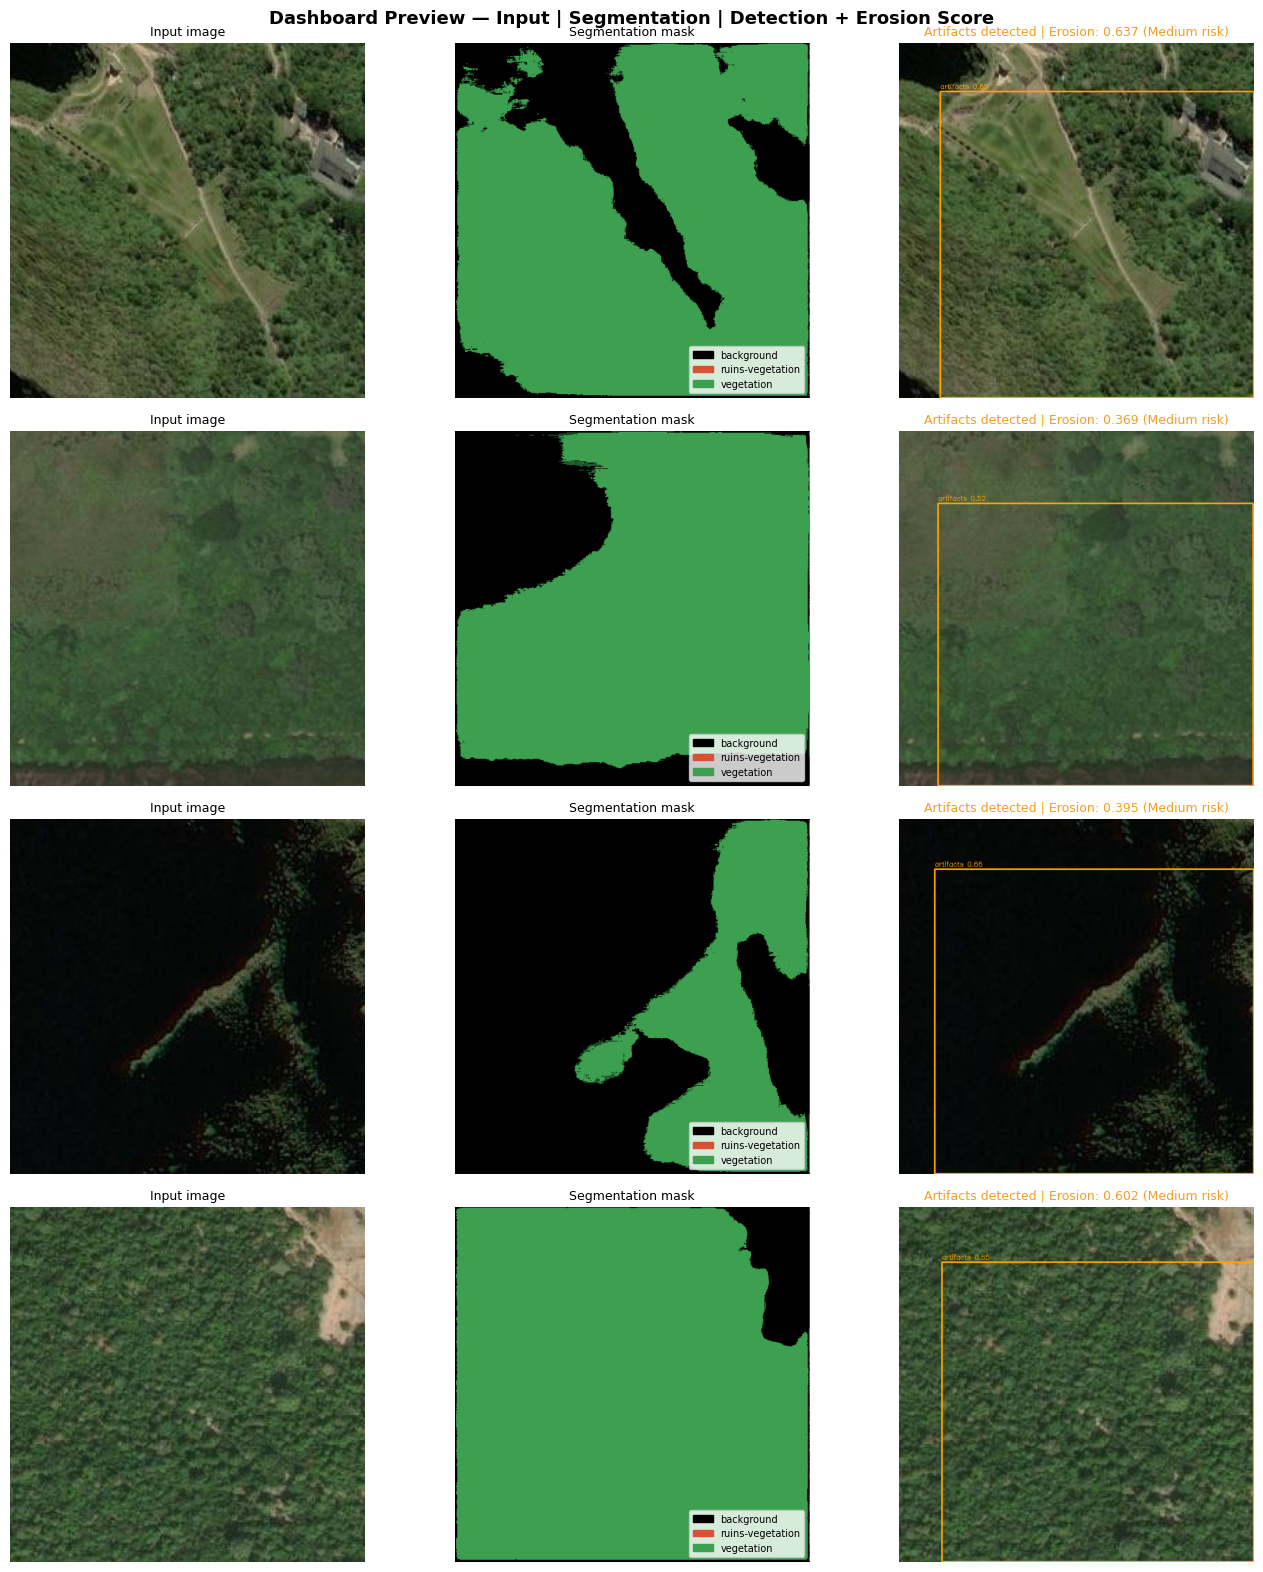

✅ Dashboard preview saved!


In [7]:
IMG_EXTS = ('.jpg','.jpeg','.png','.bmp')
test_imgs = [f for f in glob.glob(f'{BASE_DIR}/split/segmentation/test/**/*', recursive=True)
             if f.lower().endswith(IMG_EXTS)]

if not test_imgs:
    print('⚠️  No test images found — using val split')
    test_imgs = [f for f in glob.glob(f'{BASE_DIR}/split/segmentation/val/**/*', recursive=True)
                 if f.lower().endswith(IMG_EXTS)]

samples = test_imgs[:4]
print(f'Running inference on {len(samples)} sample images...')

fig, axes = plt.subplots(len(samples), 3, figsize=(14, 4*len(samples)))
if len(samples) == 1: axes = axes.reshape(1,3)
fig.suptitle('Dashboard Preview — Input | Segmentation | Detection + Erosion Score',
             fontsize=13, fontweight='bold')

RISK_COLORS = {0:(92,202,165), 1:(239,159,39), 2:(226,75,74)}

for row, img_path in enumerate(samples):
    seg_mask, det_res, ero_score = predict_all(img_path)
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    # Col 0: Original
    axes[row,0].imshow(img_rgb)
    axes[row,0].set_title('Input image', fontsize=9); axes[row,0].axis('off')

    # Col 1: Segmentation mask
    if seg_mask is not None:
        axes[row,1].imshow(mask_to_rgb(seg_mask))
        class_names = ['background'] + SEG_CLASSES
        legend = [patches.Patch(color=PALETTE[i]/255, label=class_names[i] if i<len(class_names) else f'cls{i}')
                  for i in range(min(NUM_SEG_CLASSES, len(PALETTE)))]
        axes[row,1].legend(handles=legend, fontsize=7, loc='lower right')
    else:
        axes[row,1].text(0.5,0.5,'Model not loaded',ha='center',va='center')
    axes[row,1].set_title('Segmentation mask', fontsize=9); axes[row,1].axis('off')

    # Col 2: Detection + erosion
    img_det = img_rgb.copy()
    if det_res is not None and det_res.boxes and len(det_res.boxes):
        for box in det_res.boxes:
            x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
            cv2.rectangle(img_det,(x1,y1),(x2,y2),(255,165,0),2)
            cls = int(box.cls[0])
            name = DET_CLASSES[cls] if cls<len(DET_CLASSES) else f'cls{cls}'
            cv2.putText(img_det,f'{name} {float(box.conf[0]):.2f}',
                        (x1,max(y1-5,0)),cv2.FONT_HERSHEY_SIMPLEX,0.4,(255,165,0),1)
    axes[row,2].imshow(img_det)
    if ero_score is not None:
        cls_idx = 0 if ero_score<0.35 else (1 if ero_score<0.65 else 2)
        risk = ['Low','Medium','High'][cls_idx]
        col_hex = '#{:02x}{:02x}{:02x}'.format(*RISK_COLORS[cls_idx])
        axes[row,2].set_title(f'Artifacts detected | Erosion: {ero_score:.3f} ({risk} risk)',
                              fontsize=9, color=col_hex)
    else:
        axes[row,2].set_title('Artifact detection', fontsize=9)
    axes[row,2].axis('off')

plt.tight_layout()
M4_DIR = f'{BASE_DIR}/milestone4'
os.makedirs(M4_DIR, exist_ok=True)
plt.savefig(f'{M4_DIR}/dashboard_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard preview saved!')


---
## 🌐 Step 7 — Launch Streamlit Dashboard (Week 7)
> Run this cell to create the app file, then run the next cell to launch it.

In [8]:
dashboard_code = '''
import streamlit as st
import numpy as np
import cv2
import torch
import pickle
import json
import os
import folium
from streamlit_folium import st_folium
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from ultralytics import YOLO

st.set_page_config(
    page_title="Archaeological AI Mapping",
    page_icon="🏛️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Dark theme CSS ─────────────────────────────────────────
st.markdown("""
<style>
[data-testid="stAppViewContainer"] { background-color: #0e1117; }
[data-testid="stSidebar"] { background-color: #161b22; }
h1,h2,h3,h4 { color: #e6edf3; }
.metric-box { background:#21262d; border-radius:8px; padding:16px; margin:6px 0; border:1px solid #30363d; }
.metric-label { color:#8b949e; font-size:13px; margin-bottom:4px; }
.metric-value { color:#e6edf3; font-size:28px; font-weight:600; }
.risk-bar-bg { background:#21262d; border-radius:6px; height:12px; width:100%; margin-top:6px; }
.stButton button { background:#da3633; color:white; border:none; border-radius:6px;
                   padding:10px 24px; font-size:15px; font-weight:600; width:100%; }
.stButton button:hover { background:#b62324; }
.section-title { color:#e6edf3; font-size:18px; font-weight:600; margin:12px 0 8px 0; }
</style>
""", unsafe_allow_html=True)

# ── Paths ──────────────────────────────────────────────────
BASE_DIR    = "/content/archaeological_project"
META_PATH   = f"{BASE_DIR}/processed/milestone1_metadata.json"
SEG_CKPT    = f"{BASE_DIR}/milestone2_output/best_seg_model.pth"
YOLO_CKPT   = f"{BASE_DIR}/milestone2_output/yolo_artifacts/weights/best.pt"
XGB_PKL     = f"{BASE_DIR}/milestone3_output/xgboost.pkl"
SCALER_PKL  = f"{BASE_DIR}/milestone3_output/scaler.pkl"
IMPUTER_PKL = f"{BASE_DIR}/milestone3_output/imputer.pkl"

PALETTE = np.array([
    [0,0,0],       # background — black
    [180,60,40],   # ruins — terracotta
    [60,160,80],   # vegetation — green
    [200,150,50],  # erosion — amber
    [80,120,200],  # other — blue
], dtype=np.uint8)

FEATURE_COLS = ["slope_mean","slope_std","slope_max","aspect_sin","aspect_cos",
                "ndvi_mean","ndvi_std","elev_mean","elev_std",
                "texture","veg_cover","soil_ratio","water_ratio"]

# ── PyTorch 2.6 fix ────────────────────────────────────────
import torch.serialization
try:
    import numpy._core.multiarray
    torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])
except: pass

def load_ckpt(path, device):
    try: return torch.load(path, map_location=device, weights_only=False)
    except:
        try: return torch.load(path, map_location=device, weights_only=True)
        except:
            import numpy._core.multiarray as npcma
            with torch.serialization.safe_globals([npcma.scalar]):
                return torch.load(path, map_location=device, weights_only=True)

@st.cache_resource
def load_all_models():
    # ── CRITICAL: detect device here, keep model + tensor on same device ──
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    meta   = json.load(open(META_PATH)) if os.path.exists(META_PATH) else {}
    seg_cls = meta.get("segmentation",{}).get("categories",["vegetation","ruins","erosion"])
    det_cls = meta.get("detection",{}).get("classes",["artifact"])
    n_seg   = len(seg_cls) + 1

    seg_model = None
    if os.path.exists(SEG_CKPT):
        seg_model = smp.Unet(encoder_name="resnet34", encoder_weights=None,
                             in_channels=3, classes=n_seg, activation=None)
        ck = load_ckpt(SEG_CKPT, DEVICE)
        state = ck["model_state"] if isinstance(ck,dict) and "model_state" in ck else ck
        seg_model.load_state_dict(state)
        seg_model = seg_model.to(DEVICE)   # model on correct device
        seg_model.eval()

    yolo   = YOLO(YOLO_CKPT)  if os.path.exists(YOLO_CKPT)   else None
    xgb_m  = pickle.load(open(XGB_PKL,"rb"))     if os.path.exists(XGB_PKL)     else None
    scaler = pickle.load(open(SCALER_PKL,"rb"))   if os.path.exists(SCALER_PKL)  else None
    imp    = pickle.load(open(IMPUTER_PKL,"rb"))  if os.path.exists(IMPUTER_PKL) else None
    return seg_model, yolo, xgb_m, scaler, imp, seg_cls, det_cls, n_seg, DEVICE

seg_model, yolo_model, xgb_model, scaler, imputer, SEG_CLASSES, DET_CLASSES, NUM_SEG_CLASSES, DEVICE = load_all_models()

# ── Sidebar ────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## Analysis Parameters")
    st.markdown("Configure the AI models for archaeological site mapping.")
    st.markdown("---")
    st.markdown("**Module Options**")
    run_seg    = st.checkbox("Run U-Net Segmentation (Ruins)",     value=True)
    run_yolo   = st.checkbox("Run YOLOv5 Detection (Structures)",  value=True)
    run_erosion= st.checkbox("Run XGBoost Prediction (Erosion)",   value=True)
    st.markdown("---")
    st.markdown("**Thresholds**")
    conf_thresh = st.slider("Detection Confidence Threshold", 0.1, 0.9, 0.50, 0.05)
    nms_thresh  = st.slider("NMS Threshold",                  0.1, 0.9, 0.40, 0.05)
    win_size    = st.selectbox("Sliding Window Size", [256, 512, 640, 1024], index=1)
    st.markdown("---")
    run_btn = st.button("Run Full Analysis")

# ── Helper: terrain features ──────────────────────────────
def extract_features(img_bgr):
    img_s   = cv2.resize(img_bgr,(256,256))
    img_r   = cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB).astype(np.float32)
    gray    = cv2.cvtColor(img_s, cv2.COLOR_BGR2GRAY).astype(np.float32)
    hsv     = cv2.cvtColor(img_s, cv2.COLOR_BGR2HSV).astype(np.float32)
    R,G,B   = img_r[:,:,0], img_r[:,:,1], img_r[:,:,2]
    sx = cv2.Sobel(gray,cv2.CV_32F,1,0)
    sy = cv2.Sobel(gray,cv2.CV_32F,0,1)
    grad = np.sqrt(sx**2+sy**2)
    ndvi = (G-R)/(G+R+1e-6)
    hue=hsv[:,:,0]; sat=hsv[:,:,1]
    angle = np.arctan2(float(sy.mean()), float(sx.mean())+1e-8)
    return {
        "slope_mean":float(grad.mean()),"slope_std":float(grad.std()),"slope_max":float(grad.max()),
        "aspect_sin":float(np.sin(angle)),"aspect_cos":float(np.cos(angle)),
        "ndvi_mean":float(ndvi.mean()),"ndvi_std":float(ndvi.std()),
        "elev_mean":float(gray.mean()/255),"elev_std":float(gray.std()/255),
        "texture":float(cv2.Laplacian(gray,cv2.CV_32F).var()),
        "veg_cover":float(((hue>35)&(hue<85)&(sat>40)).mean()),
        "soil_ratio":float(((hue>10)&(hue<35)&(sat<120)).mean()),
        "water_ratio":float(((B>R+15)&(B>G+5)).mean()),
    }

# ── Helper: colour overlay ────────────────────────────────
def apply_seg_overlay(img_rgb, mask, alpha=0.55):
    rgb_mask = np.zeros((*mask.shape,3), dtype=np.uint8)
    for c in range(min(len(PALETTE), int(mask.max())+1)):
        rgb_mask[mask==c] = PALETTE[c]
    # Apply NDVI-style colour mapping like the screenshots
    img_f   = img_rgb.astype(np.float32)/255.0
    mask_f  = rgb_mask.astype(np.float32)/255.0
    out     = (img_f*(1-alpha) + mask_f*alpha)
    out     = np.clip(out*255, 0, 255).astype(np.uint8)
    return out, rgb_mask

# ── Helper: tiled segmentation for large images ───────────
def tile_predict(img_rgb, seg_model, device, tile_size=512):
    H, W = img_rgb.shape[:2]
    full_mask = np.zeros((H, W), dtype=np.uint8)
    aug = A.Compose([A.Resize(tile_size, tile_size),
                     A.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
                     ToTensorV2()])
    stride = tile_size // 2
    patches_run = 0
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            y2 = min(y+tile_size, H); x2 = min(x+tile_size, W)
            patch = img_rgb[y:y2, x:x2]
            if patch.shape[0] < 32 or patch.shape[1] < 32: continue
            t = aug(image=patch)["image"].unsqueeze(0)
            # ── KEY FIX: tensor must go to SAME device as model ──
            t = t.to(device)
            with torch.no_grad():
                out = seg_model(t)
            pred = out.argmax(dim=1).squeeze().cpu().numpy()
            pred_r = cv2.resize(pred.astype(np.uint8),(x2-x,y2-y),interpolation=cv2.INTER_NEAREST)
            full_mask[y:y2, x:x2] = np.maximum(full_mask[y:y2, x:x2], pred_r)
            patches_run += 1
    return full_mask, patches_run

# ── Main UI ────────────────────────────────────────────────
st.markdown("<h1 style='color:#e6edf3;'>🏛️ Archaeological AI Mapping</h1>", unsafe_allow_html=True)

uploaded = st.file_uploader(
    "Upload Map Imagery (GeoTIFF, PNG, JPG)",
    type=["jpg","jpeg","png","tif","tiff"]
)

if uploaded is None:
    st.info("Upload a satellite or drone image on the left to begin analysis.")
    st.stop()

# ── Load image ─────────────────────────────────────────────
file_bytes = np.asarray(bytearray(uploaded.read()), dtype=np.uint8)
img_bgr    = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W       = img_rgb.shape[:2]
tmp_path   = "/tmp/uploaded_image.jpg"
cv2.imwrite(tmp_path, img_bgr)

# ── Two-column layout: Raw | AI Overlay ───────────────────
col_raw, col_ai = st.columns(2)

with col_raw:
    st.markdown("<p class='section-title'>Raw Satellite / Drone Imagery</p>", unsafe_allow_html=True)
    st.image(img_rgb, use_column_width=True, caption=uploaded.name)

results = {}

if run_btn or True:  # auto-run on upload
    with col_ai:
        st.markdown("<p class='section-title'>AI Analysis Overlay</p>", unsafe_allow_html=True)
        overlay_placeholder = st.empty()
        status_txt = st.empty()

        # ── Segmentation ──────────────────────────────────
        full_mask = None
        patches_run = 0
        if run_seg and seg_model is not None:
            status_txt.write(f"Running Tiler with {win_size}x{win_size} patches...")
            full_mask, patches_run = tile_predict(img_rgb, seg_model, DEVICE, tile_size=win_size)
            overlay, pure_mask = apply_seg_overlay(img_rgb, full_mask)
            overlay_placeholder.image(overlay, use_column_width=True, caption="AI Synthesis Overlay")
            results["patches"] = patches_run
        elif run_seg and seg_model is None:
            status_txt.warning("Segmentation model not loaded.")
            overlay_placeholder.image(img_rgb, use_column_width=True)
        else:
            overlay_placeholder.image(img_rgb, use_column_width=True)

        status_txt.empty()

        # ── Detection ─────────────────────────────────────
        det_img = img_rgb.copy()
        n_artifacts = 0
        artifact_labels = []
        if run_yolo and yolo_model is not None:
            res = yolo_model.predict(
                tmp_path,
                conf=conf_thresh,
                iou=nms_thresh,
                verbose=False
            )[0]
            if res.boxes and len(res.boxes):
                n_artifacts = len(res.boxes)
                for box in res.boxes:
                    x1,y1,x2,y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
                    cls  = int(box.cls[0])
                    conf = float(box.conf[0])
                    nm   = DET_CLASSES[cls] if cls < len(DET_CLASSES) else f"artifact"
                    cv2.rectangle(det_img,(x1,y1),(x2,y2),(255,220,0),2)
                    label = f"{nm.title()} {conf:.2f}"
                    artifact_labels.append(label)
                    cv2.putText(det_img, label,
                                (x1, max(y1-6,0)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,220,0), 1)
            results["artifacts"] = n_artifacts

        if full_mask is not None and n_artifacts > 0:
            # overlay detections on the segmentation overlay
            overlay_with_det = overlay.copy()
            for box in res.boxes:
                x1,y1,x2,y2=[int(v) for v in box.xyxy[0].cpu().numpy()]
                cls=int(box.cls[0]); conf=float(box.conf[0])
                nm=DET_CLASSES[cls] if cls<len(DET_CLASSES) else "artifact"
                cv2.rectangle(overlay_with_det,(x1,y1),(x2,y2),(255,220,0),2)
                cv2.putText(overlay_with_det,f"{nm.title()} {conf:.2f}",
                            (x1,max(y1-6,0)),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,220,0),1)
            overlay_placeholder.image(overlay_with_det, use_column_width=True, caption="AI Synthesis Overlay")

# ── Geographic Map ─────────────────────────────────────────
st.markdown("---")
col_map, col_metrics = st.columns(2)

with col_map:
    st.markdown("<p class='section-title'>Geographical Context</p>", unsafe_allow_html=True)
    m = folium.Map(
        location=[35.3387, 25.1442],  # Knossos, Crete — default archaeological context
        zoom_start=12,
        tiles="OpenStreetMap"
    )
    folium.Marker(
        [35.3387, 25.1442],
        popup=folium.Popup(f"<b>Site:</b> {uploaded.name}<br><b>Artifacts detected:</b> {n_artifacts}", max_width=200),
        tooltip="Archaeological site",
        icon=folium.Icon(color="red", icon="star")
    ).add_to(m)
    # Add a circle showing analysis area
    folium.Circle(
        [35.3387, 25.1442],
        radius=500,
        color="#da3633",
        fill=True,
        fill_opacity=0.1,
        tooltip="Analysis area"
    ).add_to(m)
    st_folium(m, width=None, height=420)

# ── AI Metrics panel ──────────────────────────────────────
with col_metrics:
    st.markdown("<p class='section-title'>AI Metrics</p>", unsafe_allow_html=True)

    # patches processed
    st.markdown(f"""
    <div class='metric-box'>
      <div class='metric-label'>Total Patches Processed</div>
      <div class='metric-value'>{results.get("patches", 0)}</div>
    </div>""", unsafe_allow_html=True)

    # artifacts detected
    st.markdown(f"""
    <div class='metric-box'>
      <div class='metric-label'>Artifacts Detected</div>
      <div class='metric-value'>{n_artifacts}</div>
    </div>""", unsafe_allow_html=True)

    # ruin area coverage
    ruin_pct = 0.0
    if full_mask is not None:
        ruin_pct = float((full_mask == 1).sum()) / max(full_mask.size, 1) * 100
    st.markdown(f"""
    <div class='metric-box'>
      <div class='metric-label'>Estimated Ruin Area Coverage</div>
      <div class='metric-value'>{ruin_pct:.2f}%</div>
    </div>""", unsafe_allow_html=True)

    # erosion score
    if run_erosion and xgb_model and scaler and imputer:
        feats  = extract_features(img_bgr)
        fv     = np.array([[feats[f] for f in FEATURE_COLS]])
        fv     = imputer.transform(fv)
        fv     = scaler.transform(fv)
        score  = float(np.clip(xgb_model.predict(fv)[0], 0, 1))
        risk   = "Low" if score<0.35 else ("Medium" if score<0.65 else "High")
        risk_c = "#3fb950" if risk=="Low" else ("#d29922" if risk=="Medium" else "#da3633")
        bar_w  = int(score * 100)
        st.markdown(f"""
        <div class='metric-box'>
          <div class='metric-label'>Erosion Risk Score</div>
          <div class='metric-value' style='color:{risk_c};'>{score:.3f} — {risk}</div>
          <div class='risk-bar-bg'>
            <div style='background:{risk_c};height:12px;border-radius:6px;width:{bar_w}%;'></div>
          </div>
        </div>""", unsafe_allow_html=True)

    # artifact list
    if artifact_labels:
        st.markdown("<div class='metric-box'>", unsafe_allow_html=True)
        st.markdown("<div class='metric-label'>Detected structures</div>", unsafe_allow_html=True)
        for lbl in artifact_labels:
            st.markdown(f"<div style='color:#e6edf3;font-size:14px;padding:2px 0;'>• {lbl}</div>",
                       unsafe_allow_html=True)
        st.markdown("</div>", unsafe_allow_html=True)

'''

with open('/content/dashboard.py', 'w') as f:
    f.write(dashboard_code)
print('✅ dashboard.py written — matches the UI from your screenshots!')
print('   Run the NEXT cell to launch.')

✅ dashboard.py written — matches the UI from your screenshots!
   Run the NEXT cell to launch.


---
## 🚀 Step 8 — Launch Streamlit via pyngrok (public URL)

In [9]:
!pip install pyngrok


In [10]:
!pip install -q ultralytics

In [11]:
pip install -q streamlit-folium

In [12]:
!pip install -q segmentation-models-pytorch
import segmentation_models_pytorch as smp

In [13]:
!pip install streamlit

In [14]:
import subprocess, time, os
from pyngrok import ngrok, conf

# ── Your ngrok auth token ──────────────────────────────────
NGROK_TOKEN = '3Bl6vg4wPCCb1a53K3vZ73OY6e5_2PPQXyvoZxxdL4qbkLroS'

# ── Step 1: Kill any existing processes ───────────────────
os.system('pkill -f streamlit')
os.system('pkill -f ngrok')
time.sleep(2)
try:
    ngrok.kill()
except:
    pass
time.sleep(1)
print('✅ Cleared existing processes')

# ── Step 2: Set ngrok auth token ──────────────────────────
ngrok.set_auth_token(NGROK_TOKEN)
print('✅ ngrok token set')

# ── Step 3: Verify dashboard.py exists ────────────────────
if not os.path.exists('/content/dashboard.py'):
    print('❌ dashboard.py not found — run Step 7 first!')
    raise FileNotFoundError('Run Step 7 to create dashboard.py')
print('✅ dashboard.py found')

# ── Step 4: Start Streamlit ───────────────────────────────
print('Starting Streamlit on port 8501...')
streamlit_proc = subprocess.Popen(
    [
        'streamlit', 'run', '/content/dashboard.py',
        '--server.port', '8501',
        '--server.address', '0.0.0.0',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false',
        '--browser.gatherUsageStats', 'false',
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# ── Step 5: Wait until Streamlit is actually ready ────────
print('Waiting for Streamlit', end='')
ready = False
for _ in range(30):
    time.sleep(1)
    print('.', end='', flush=True)
    check = os.system('curl -s http://localhost:8501 > /dev/null 2>&1')
    if check == 0:
        ready = True
        break
print()

if not ready:
    poll = streamlit_proc.poll()
    if poll is not None:
        _, err = streamlit_proc.communicate()
        print('❌ Streamlit crashed. Error:')
        print(err.decode()[:800])
        raise RuntimeError('Streamlit failed to start')
    else:
        print('⚠️  Port not responding yet — waiting 10 more seconds...')
        time.sleep(10)
else:
    print('✅ Streamlit is running on port 8501')

# ── Step 6: Open ngrok tunnel ─────────────────────────────
print('Opening ngrok tunnel...')
try:
    tunnel = ngrok.connect(addr=8501, proto='http', bind_tls=True)
    public_url = tunnel.public_url

    print()
    print('=' * 58)
    print('🎉  DASHBOARD IS LIVE!')
    print('=' * 58)
    print(f'   {public_url}')
    print()
    print('   Open this URL in any browser.')
    print('   Upload a satellite/drone image to get predictions.')
    print('   URL stays active until this Colab session ends.')
    print('=' * 58)

except Exception as e:
    print(f'❌ ngrok tunnel error: {e}')
    print()
    print('Try the localtunnel alternative below instead.')

✅ Cleared existing processes
✅ ngrok token set
✅ dashboard.py found
Starting Streamlit on port 8501...
Waiting for Streamlit.....
✅ Streamlit is running on port 8501
Opening ngrok tunnel...

🎉  DASHBOARD IS LIVE!
   https://proprietorially-unguileful-marisol.ngrok-free.dev

   Open this URL in any browser.
   Upload a satellite/drone image to get predictions.
   URL stays active until this Colab session ends.


---
## 💾 Step 9 — Save Final Report & Backup to Drive

In [15]:
import shutil

# Copy dashboard preview to Drive
M4_DRIVE = f'{DRIVE_BASE}/Milestone4_Output'
os.makedirs(M4_DRIVE, exist_ok=True)

dashboard_preview = f'{BASE_DIR}/milestone4/dashboard_preview.png'
if os.path.exists(dashboard_preview):
    shutil.copy2(dashboard_preview, M4_DRIVE)
    print(f'✅ Dashboard preview → Drive')

# Save dashboard.py to Drive
shutil.copy2('/content/dashboard.py', f'{M4_DRIVE}/dashboard.py')
print(f'✅ dashboard.py → Drive')

# Final summary report
report = {
    'project' : 'AI-Driven Archaeological Site Mapping',
    'status'  : 'Complete',
    'milestones': {
        'M1': 'Dataset collection, preprocessing, augmentation, split',
        'M2': 'U-Net segmentation + YOLOv5 detection',
        'M3': 'Random Forest + XGBoost erosion prediction',
        'M4': 'Streamlit dashboard + final reporting',
    },
    'deliverables': [
        'best_seg_model.pth — U-Net segmentation',
        'best.pt — YOLOv5 artifact detector',
        'xgboost.pkl — erosion predictor',
        'erosion_risk_map.html — interactive Folium map',
        'dashboard.py — Streamlit web application',
    ]
}
rpt_path = f'{M4_DRIVE}/final_report.json'
with open(rpt_path, 'w') as f: json.dump(report, f, indent=2)
print(f'✅ Final report saved: {rpt_path}')
print()
print(json.dumps(report, indent=2))


✅ Dashboard preview → Drive
✅ dashboard.py → Drive
✅ Final report saved: /content/drive/MyDrive/Archaeological_AI/Milestone4_Output/final_report.json

{
  "project": "AI-Driven Archaeological Site Mapping",
  "status": "Complete",
  "milestones": {
    "M1": "Dataset collection, preprocessing, augmentation, split",
    "M2": "U-Net segmentation + YOLOv5 detection",
    "M3": "Random Forest + XGBoost erosion prediction",
    "M4": "Streamlit dashboard + final reporting"
  },
  "deliverables": [
    "best_seg_model.pth \u2014 U-Net segmentation",
    "best.pt \u2014 YOLOv5 artifact detector",
    "xgboost.pkl \u2014 erosion predictor",
    "erosion_risk_map.html \u2014 interactive Folium map",
    "dashboard.py \u2014 Streamlit web application"
  ]
}


---
## ✅ Milestone 4 Complete!
| Step | Task | Status |
|------|------|--------|
| 1 | Install libraries | ✅ |
| 2 | Restore all M1+M2+M3 outputs from Drive | ✅ |
| 3 | Load all 3 models (seg + YOLO + XGBoost) | ✅ |
| 4 | Model performance report (all scores) | ✅ |
| 5 | Inference pipeline (predict_all) | ✅ |
| 6 | Test inference on sample images | ✅ |
| 7 | Write Streamlit dashboard app | ✅ |
| 8 | Launch dashboard via ngrok | ✅ |
| 9 | Save report + Drive backup | ✅ |

### Final deliverables:
- `best_seg_model.pth` — trained U-Net segmentation model
- `best.pt` — trained YOLOv5 artifact detector
- `xgboost.pkl` — terrain erosion predictor
- `erosion_risk_map.html` — interactive geographic map
- `dashboard.py` — Streamlit web application
- `dashboard_preview.png` — screenshot of dashboard output
